In [37]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)


In [40]:
from src.data_utils import load_data, basic_data_check,get_feature_target
df_path = DATA_DIR / "final_project_data.csv"
df = load_data(df_path)
basic_data_check(df)

X, y, ids = get_feature_target(df)

print('\nX shape:', X.shape)
print('y shape:', y.shape)
print('ids shape:', ids.shape)

Shape: (12424, 26)
Columns: ['subject_id', 'hadm_id', 'stay_id', 'intime', 'heart_rate_mean', 'sbp_mean', 'dbp_mean', 'mbp_mean', 'resp_rate_mean', 'temperature_mean', 'spo2_mean', 'wbc_min', 'wbc_max', 'platelets_min', 'hemoglobin_min', 'creatinine_max', 'sodium_min', 'sodium_max', 'glucose_max', 'albumin_min', 'lactate_max', 'ph_min', 'po2_min', 'pco2_max', 'sofa', 'hospital_expire_flag']

Target distribution:
hospital_expire_flag
0    9698
1    2726
Name: count, dtype: int64

Missing values:
albumin_min             47.883129
lactate_max             32.807469
pco2_max                21.555055
ph_min                  21.555055
po2_min                 21.547006
temperature_mean         1.827109
wbc_max                  0.861236
wbc_min                  0.861236
glucose_max              0.853187
platelets_min            0.845138
hemoglobin_min           0.829041
sodium_min               0.804894
sodium_max               0.804894
creatinine_max           0.748551
mbp_mean                

In [3]:
X.head()

,heart_rate_mean,sbp_mean,dbp_mean,mbp_mean,resp_rate_mean,temperature_mean,spo2_mean,wbc_min,wbc_max,platelets_min,...,creatinine_max,sodium_min,sodium_max,glucose_max,albumin_min,lactate_max,ph_min,po2_min,pco2_max,sofa
0,78.240000,110.862069,62.448276,80.793103,17.185185,36.916667,99.500000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,122.500000,NaN,NaN,NaN,32.000000,NaN,92.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,73.941176,116.323529,83.764706,94.088235,19.236111,37.221667,97.823529,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,62.673913,118.327273,55.418182,75.500000,18.040000,37.128333,99.630435,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,101.666667,NaN,NaN,NaN,15.500000,36.475000,94.166667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7


In [39]:
from src.cv_runner import run_cv_model
from src.results_utils import summarize_metrics_results
import numpy as np

def dummy_model(X_train, y_train, X_test):
    p = float(np.mean(y_train))
    return np.full(shape=len(X_test), fill_value=p)
    

In [5]:
metrics_df, preds_df = run_cv_model(
    X=X,
    y=y,
    ids=ids,
    model_name="Dummy",
    fit_predict_fn=dummy_model
)

metrics_df

,auc_roc,average_precision,brier_score,model,fold
0,0.5,0.219316,0.171216,Dummy,1
1,0.5,0.219316,0.171216,Dummy,2
2,0.5,0.219316,0.171216,Dummy,3
3,0.5,0.219718,0.171442,Dummy,4
4,0.5,0.219404,0.171266,Dummy,5


In [6]:
summarize_metrics_results(metrics_df)

auc_roc      average_precision         brier_score        
         mean  std              mean     std        mean     std
model                                                           
Dummy     0.5  0.0            0.2194  0.0002      0.1713  0.0001

--- 
Test run logistic regression model

In [7]:
from src.models_classical import fit_predict_logistic_regression

In [8]:
lg_metrics_df, lg_preds_df = run_cv_model(
    X=X,
    y=y,
    ids=ids,
    model_name='Logistic Regression',
    fit_predict_fn=fit_predict_logistic_regression
)

/Users/krishuang/miniforge3/envs/nlp_transformers313/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/krishuang/miniforge3/envs/nlp_transformers313/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/krishuang/miniforge3/envs/nlp_transformers313/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWa

In [9]:
lg_metrics_df

,auc_roc,average_precision,brier_score,model,fold
0,0.731459,0.488796,0.202116,Logistic Regression,1
1,0.742798,0.504140,0.201343,Logistic Regression,2
2,0.726594,0.469277,0.204785,Logistic Regression,3
3,0.719735,0.468914,0.208265,Logistic Regression,4
4,0.716188,0.468290,0.210712,Logistic Regression,5


In [10]:
lg_preds_df

,subject_id,hadm_id,stay_id,intime,model,fold,y_true,y_prob
0,12980052,27167994,37484422,2130-04-26T20:30:38,Logistic Regression,1,0,0.187167
1,15301569,25599780,33337491,2146-05-27T02:36:00,Logistic Regression,1,0,0.263034
2,11467782,29387444,31276761,2184-11-30T18:43:00,Logistic Regression,1,0,0.183318
3,11871434,24994500,31855550,2142-11-23T01:32:50,Logistic Regression,1,0,0.425818
4,14679785,20300692,32024819,2160-06-08T15:33:04,Logistic Regression,1,1,0.387265
...,...,...,...,...,...,...,...,...
12419,12130785,23878621,36423135,2167-01-17T00:32:00,Logistic Regression,5,0,0.395183
12420,19287620,26586557,38818414,2155-01-21T05:27:00,Logistic Regression,5,1,0.893648
12421,16711075,22347991,30191018,2123-05-24T02:15:35,Logistic Regression,5,0,0.240104
12422,18833064,28057717,30280973,2208-08-26T13:29:31,Logistic Regression,5,1,0.576728


In [11]:
lg_summary_df = summarize_metrics_results(lg_metrics_df)
lg_summary_df.head()


auc_roc         average_precision         brier_score  \
                       mean     std              mean     std        mean   
model                                                                       
Logistic Regression  0.7274  0.0105            0.4799  0.0161      0.2054   

                            
                       std  
model                       
Logistic Regression  0.004

In [ ]:
lg_metrics_df.to_csv(METRICS_DIR / "logistic_regression_fold_metrics.csv", index=False)
lg_preds_df.to_csv(PREDICTIONS_DIR / "logistic_regression_preds.csv", index=False)
lg_summary_df.to_csv(METRICS_DIR / "logistic_regression_summary.csv", index=False)


In [12]:
import importlib
import src.results_utils

importlib.reload(src.results_utils)
from src.results_utils import plot_calibration_curve

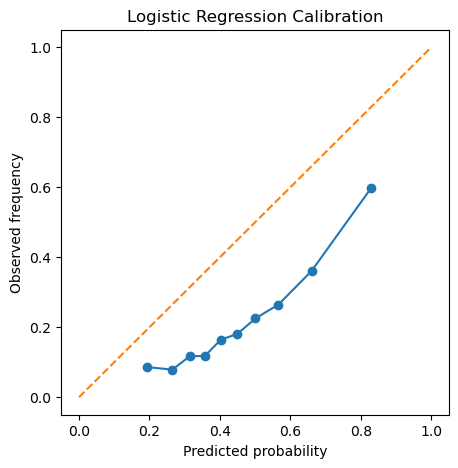

In [13]:
plot_calibration_curve(lg_preds_df, 'Logistic Regression')

## Comment 
* Logistic regression achieved a mean AUROC of 0.73 (±0.01) across the five folds, indicating moderate discrimination ability. 
* The corresponding AUPRC was 0.48 (±0.02), substantially above the class prevalence of 0.22, suggesting meaningful precision-recall performance in the imbalanced mortality prediction setting. 
* The Brier score of 0.21 indicates reasonably calibrated probability estimates.
* From the calibration curve, we can see that the logistic regression is overpredicting mortality risk. 

--- 
Test run XGBoost model

In [15]:
importlib.reload(src.models_classical)

from src.models_classical import fit_predict_xgboost

In [16]:
xgb_metrics_df, xgb_preds_df = run_cv_model(
    X=X,
    y=y,
    ids=ids,
    model_name='XGBoost',
    fit_predict_fn=fit_predict_xgboost
)

In [17]:
xgb_metrics_df

,auc_roc,average_precision,brier_score,model,fold
0,0.747112,0.518865,0.141817,XGBoost,1
1,0.744713,0.521786,0.141735,XGBoost,2
2,0.750153,0.500442,0.143804,XGBoost,3
3,0.735356,0.491431,0.145408,XGBoost,4
4,0.731421,0.498953,0.145233,XGBoost,5


In [18]:
xgb_preds_df

,subject_id,hadm_id,stay_id,intime,model,fold,y_true,y_prob
0,12980052,27167994,37484422,2130-04-26T20:30:38,XGBoost,1,0,0.198762
1,15301569,25599780,33337491,2146-05-27T02:36:00,XGBoost,1,0,0.270861
2,11467782,29387444,31276761,2184-11-30T18:43:00,XGBoost,1,0,0.095182
3,11871434,24994500,31855550,2142-11-23T01:32:50,XGBoost,1,0,0.280197
4,14679785,20300692,32024819,2160-06-08T15:33:04,XGBoost,1,1,0.599796
...,...,...,...,...,...,...,...,...
12419,12130785,23878621,36423135,2167-01-17T00:32:00,XGBoost,5,0,0.490926
12420,19287620,26586557,38818414,2155-01-21T05:27:00,XGBoost,5,1,0.816310
12421,16711075,22347991,30191018,2123-05-24T02:15:35,XGBoost,5,0,0.105125
12422,18833064,28057717,30280973,2208-08-26T13:29:31,XGBoost,5,1,0.240787


In [21]:
xgb_summary_df = summarize_metrics_results(xgb_metrics_df)
xgb_summary_df

auc_roc        average_precision         brier_score        
           mean    std              mean     std        mean     std
model                                                               
XGBoost  0.7418  0.008            0.5063  0.0133      0.1436  0.0018

In [ ]:
xgb_metrics_df.to_csv(METRICS_DIR / "xgboost_fold_metrics.csv", index=False)
xgb_preds_df.to_csv(PREDICTIONS_DIR / "xgboost_preds.csv", index=False)
xgb_summary_df.to_csv(METRICS_DIR / "xgboost_summary.csv", index=False)

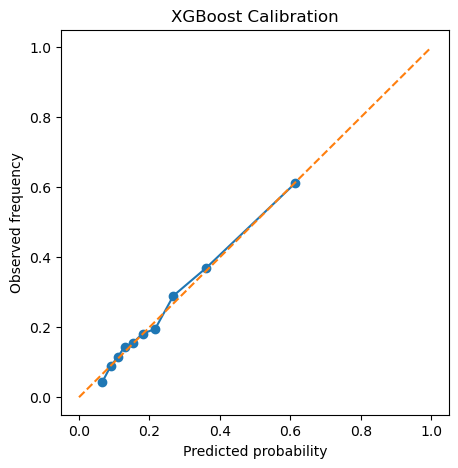

In [20]:
plot_calibration_curve(xgb_preds_df, 'XGBoost')

## Comment 
* AUCROC: 0.7418(±0.008) increased from 0.727 in the logistic regression case but not by much, indicating that most predictive signal in the feature set is captured by simple linear relationships, with limited additional nonlinear interaction structure.
* This could mean that interpretability models like EBM / GA2M might perform nearly as well as XGBoost.
* Well calibrated as predicted probability matches closely the observed frequency, supported by significant drop in Brier score, which is the squared difference between y_true and y_pred_prob. 


--- 
Test run EBM/GA2M model

In [30]:
importlib.reload(src.models_classical)

from src.models_classical import fit_predict_ebm

In [31]:
ebm_metrics_df, ebm_preds_df = run_cv_model(
    X=X,
    y=y,
    ids=ids,
    model_name='EBM',
    fit_predict_fn=fit_predict_ebm
)

/Users/krishuang/miniforge3/envs/nlp_transformers313/lib/python3.13/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(
/Users/krishuang/miniforge3/envs/nlp_transformers313/lib/python3.13/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(
/Users/krishuang/miniforge3/envs/nlp_transformers313/lib/python3.13/site-packages/interp

In [32]:
ebm_metrics_df

,auc_roc,average_precision,brier_score,model,fold
0,0.745777,0.517812,0.142133,EBM,1
1,0.751134,0.538565,0.139449,EBM,2
2,0.748099,0.503386,0.143671,EBM,3
3,0.743087,0.495843,0.144564,EBM,4
4,0.735873,0.494138,0.145916,EBM,5


In [33]:
ebm_preds_df

,subject_id,hadm_id,stay_id,intime,model,fold,y_true,y_prob
0,12980052,27167994,37484422,2130-04-26T20:30:38,EBM,1,0,0.134825
1,15301569,25599780,33337491,2146-05-27T02:36:00,EBM,1,0,0.182231
2,11467782,29387444,31276761,2184-11-30T18:43:00,EBM,1,0,0.053977
3,11871434,24994500,31855550,2142-11-23T01:32:50,EBM,1,0,0.291305
4,14679785,20300692,32024819,2160-06-08T15:33:04,EBM,1,1,0.767452
...,...,...,...,...,...,...,...,...
12419,12130785,23878621,36423135,2167-01-17T00:32:00,EBM,5,0,0.330584
12420,19287620,26586557,38818414,2155-01-21T05:27:00,EBM,5,1,0.788330
12421,16711075,22347991,30191018,2123-05-24T02:15:35,EBM,5,0,0.268750
12422,18833064,28057717,30280973,2208-08-26T13:29:31,EBM,5,1,0.518561


In [34]:
ebm_summary_df = summarize_metrics_results(ebm_metrics_df)
ebm_summary_df

auc_roc         average_precision         brier_score        
         mean     std              mean     std        mean     std
model                                                              
EBM    0.7448  0.0058            0.5099  0.0185      0.1431  0.0025

In [ ]:
ebm_metrics_df.to_csv(METRICS_DIR / "ebm_fold_metrics.csv", index=False)
ebm_preds_df.to_csv(PREDICTIONS_DIR / "ebm_preds.csv", index=False)
ebm_summary_df.to_csv(METRICS_DIR / "ebm_summary.csv", index=False)

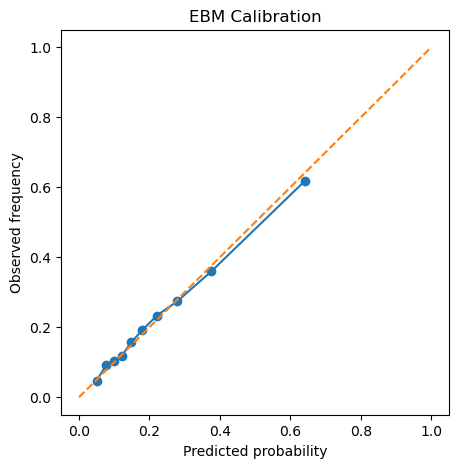

In [36]:
plot_calibration_curve(ebm_preds_df, 'EBM')